In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#Random Sampling

In [2]:
np.random.seed(42)
df = pd.DataFrame({
    'Student_ID': range(1,101),
    'Name': [f'Student_{i}'for i in range(1,101)],
    'Gender': np.random.choice(['Male','Female'],size=100),
    'Age': np.random.randint(18,25,size=100),
    'Department': np.random.choice(['Computer Science', 'Mathematics', 'Physics'], size=100),
    'Marks': np.random.randint(40, 101, size=100),

})

In [3]:
print("Population Size", len(df))
df.head(10)

Population Size 100


,Student_ID,Name,Gender,Age,Department,Marks
0,1,Student_1,Male,24,Computer Science,79
1,2,Student_2,Female,19,Computer Science,40
2,3,Student_3,Male,19,Physics,50
3,4,Student_4,Male,21,Physics,67
4,5,Student_5,Male,19,Physics,96
5,6,Student_6,Female,19,Mathematics,64
6,7,Student_7,Male,23,Mathematics,89
7,8,Student_8,Male,21,Mathematics,62
8,9,Student_9,Male,23,Computer Science,70
9,10,Student_10,Female,24,Mathematics,69


In [4]:
df


,Student_ID,Name,Gender,Age,Department,Marks
0,1,Student_1,Male,24,Computer Science,79
1,2,Student_2,Female,19,Computer Science,40
2,3,Student_3,Male,19,Physics,50
3,4,Student_4,Male,21,Physics,67
4,5,Student_5,Male,19,Physics,96
...,...,...,...,...,...,...
95,96,Student_96,Female,24,Physics,66
96,97,Student_97,Female,24,Computer Science,66
97,98,Student_98,Female,22,Computer Science,73
98,99,Student_99,Female,24,Physics,60


In [5]:
print(df['Department'].value_counts())
print("\n Gender distribution")
print(df['Gender'].value_counts())
print("\n Basic Statistics")
print(df['Marks'].describe())

Department
Computer Science    34
Physics             34
Mathematics         32
Name: count, dtype: int64

 Gender distribution
Gender
Female    56
Male      44
Name: count, dtype: int64

 Basic Statistics
count    100.000000
mean      70.740000
std       17.185629
min       40.000000
25%       57.750000
50%       72.000000
75%       87.000000
max      100.000000
Name: Marks, dtype: float64


#Simple Random Sampling

In [6]:
simple_random_sample = df.sample(n=10, random_state=42)
print(simple_random_sample)

    Student_ID        Name  Gender  Age        Department  Marks
83          84  Student_84  Female   19  Computer Science     90
53          54  Student_54  Female   21  Computer Science     64
70          71  Student_71  Female   20           Physics     53
45          46  Student_46  Female   22  Computer Science     88
44          45  Student_45  Female   20       Mathematics     50
39          40  Student_40    Male   20           Physics     93
22          23  Student_23  Female   18  Computer Science     40
80          81  Student_81    Male   24       Mathematics     87
10          11  Student_11    Male   24  Computer Science     81
0            1   Student_1    Male   24  Computer Science     79


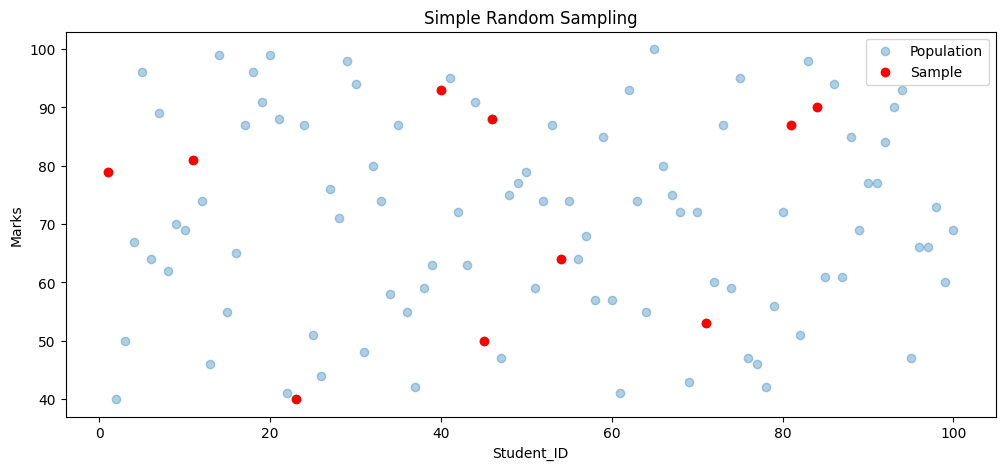

In [7]:
plt.figure(figsize=(12,5))
plt.scatter(df['Student_ID'], df['Marks'], alpha=0.35, label='Population')
plt.scatter(simple_random_sample['Student_ID'],
            simple_random_sample['Marks'], color='red', label='Sample')
plt.xlabel('Student_ID')
plt.ylabel('Marks')
plt.title('Simple Random Sampling')
plt.legend()
plt.show()

#Systematic Sampling

In [9]:
N = len(df)
n=10
k= N//n
start= np.random.randint(0,k)
systematic_sample= df.iloc[start::k].head(n)
print("Sampling interval k =",k)
print("Starting position=", start)
systematic_sample

Sampling interval k = 10
Starting position= 0


,Student_ID,Name,Gender,Age,Department,Marks
0,1,Student_1,Male,24,Computer Science,79
10,11,Student_11,Male,24,Computer Science,81
20,21,Student_21,Female,22,Mathematics,88
30,31,Student_31,Male,22,Physics,48
40,41,Student_41,Male,18,Physics,95
50,51,Student_51,Male,21,Physics,59
60,61,Student_61,Male,20,Physics,41
70,71,Student_71,Female,20,Physics,53
80,81,Student_81,Male,24,Mathematics,87
90,91,Student_91,Female,21,Physics,77


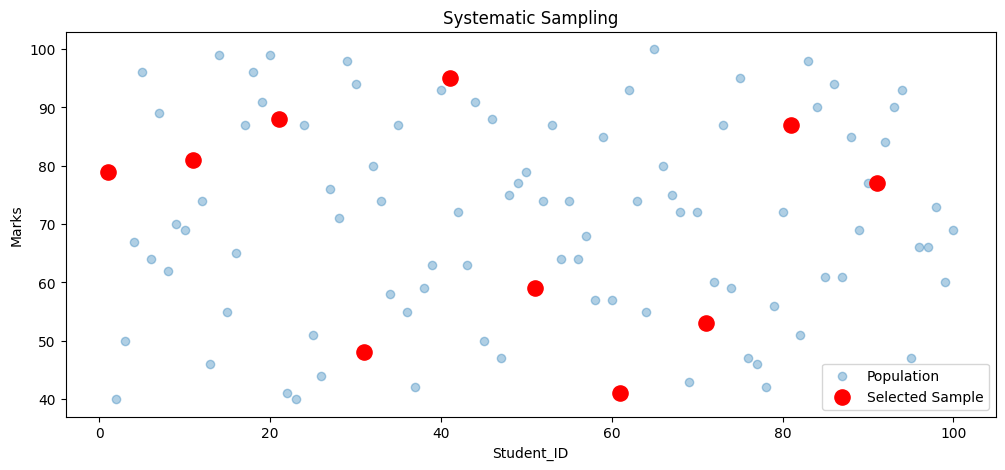

In [11]:
plt.figure(figsize=(12,5))

plt.scatter(df['Student_ID'], df['Marks'], alpha=0.35, label='Population')
plt.scatter(systematic_sample['Student_ID'],
            systematic_sample['Marks'],
            color='red', s=120, label='Selected Sample')
plt.xlabel('Student_ID')
plt.ylabel('Marks')
plt.title('Systematic Sampling')
plt.legend()
plt.show()

#Stratified Sampling

In [13]:
sample_size=20
stratified_sample, remaining = train_test_split(df, test_size=0.80, stratify=df['Department'], random_state=42)


In [15]:
stratified_sample

,Student_ID,Name,Gender,Age,Department,Marks
52,53,Student_53,Male,18,Computer Science,87
23,24,Student_24,Female,21,Computer Science,87
62,63,Student_63,Male,23,Computer Science,74
67,68,Student_68,Male,22,Computer Science,72
65,66,Student_66,Female,18,Mathematics,80
75,76,Student_76,Female,24,Physics,47
74,75,Student_75,Male,24,Computer Science,95
4,5,Student_5,Male,19,Physics,96
5,6,Student_6,Female,19,Mathematics,64
13,14,Student_14,Male,21,Mathematics,99


Original department proportions:
Department
Computer Science    0.34
Physics             0.34
Mathematics         0.32
Name: proportion, dtype: float64

Stratified sample department proportions:
Department
Computer Science    0.35
Physics             0.35
Mathematics         0.30
Name: proportion, dtype: float64


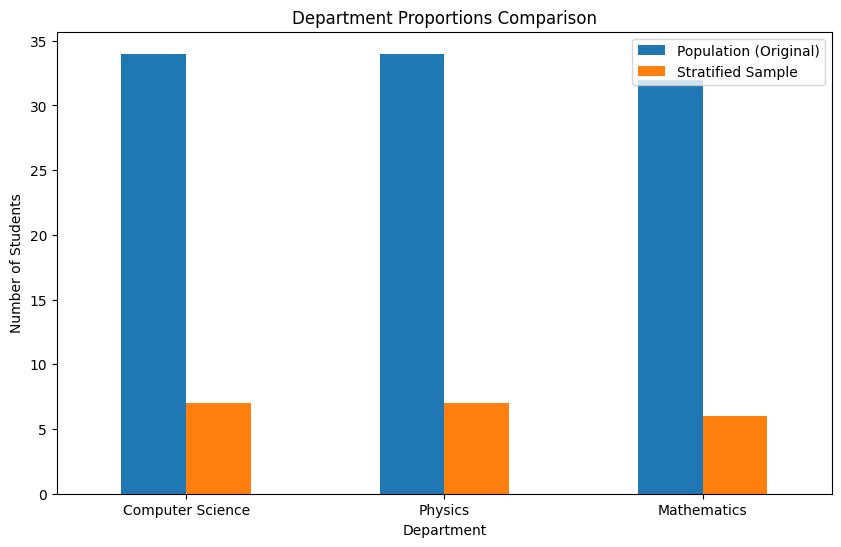

In [16]:
print("Original department proportions:")
print(df['Department'].value_counts(normalize=True).round(2))

print("\nStratified sample department proportions:")
print(stratified_sample['Department'].value_counts(normalize=True).round(2))

comparison = pd.DataFrame({
    'Population (Original)': df['Department'].value_counts(),
    'Stratified Sample': stratified_sample['Department'].value_counts()
}).fillna(0)

comparison.plot(kind='bar', figsize=(10, 6))
plt.title('Department Proportions Comparison')
plt.xlabel('Department')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()

#Cluster Sampling

In [23]:
clusters= df['Department'].unique()
selected_cluster= np.random.choice(clusters,size=2,replace=False)
cluster_sample= df[df['Department'].isin(selected_cluster)]
print("Selected clusters:", selected_cluster)
print("Sample size:", len(cluster_sample))
cluster_sample.head(10);

Selected clusters: ['Physics' 'Mathematics']
Sample size: 66


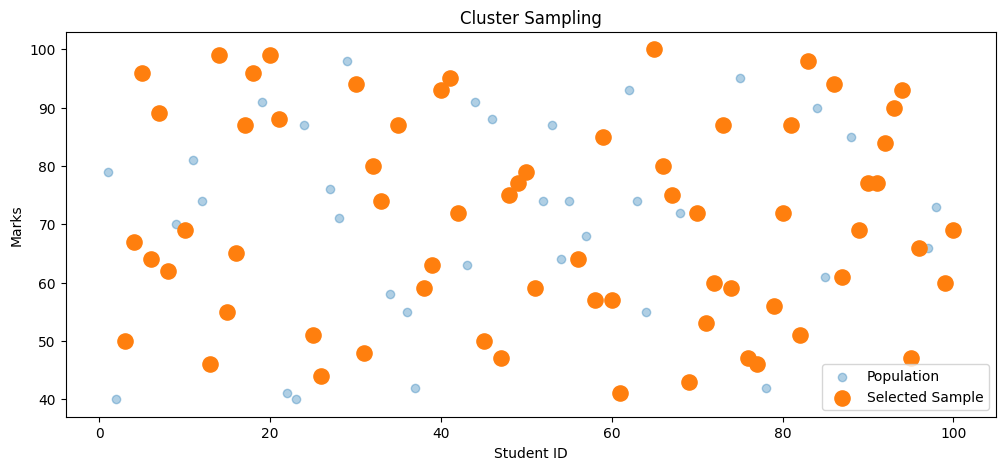

In [24]:
plt.figure(figsize=(12,5))

plt.scatter(df['Student_ID'], df['Marks'],
            alpha=0.35, label='Population')

plt.scatter(cluster_sample['Student_ID'],
            cluster_sample['Marks'],
            s=120, label='Selected Sample')

plt.xlabel('Student ID')
plt.ylabel('Marks')
plt.title('Cluster Sampling')
plt.legend()
plt.show()

#Quota Sampling

In [25]:
male_sample = df[df['Gender'] == 'Male'].sample(n=5, random_state=42)
female_sample = df[df['Gender'] == 'Female'].sample(n=5, random_state=42)
quota_sample = pd.concat([male_sample, female_sample])
print(quota_sample['Gender'].value_counts())
print("Quota Sample:")
quota_sample

Gender
Male      5
Female    5
Name: count, dtype: int64
Quota Sample:


,Student_ID,Name,Gender,Age,Department,Marks
78,79,Student_79,Male,20,Mathematics,56
52,53,Student_53,Male,18,Computer Science,87
54,55,Student_55,Male,19,Computer Science,74
74,75,Student_75,Male,24,Computer Science,95
67,68,Student_68,Male,22,Computer Science,72
1,2,Student_2,Female,19,Computer Science,40
17,18,Student_18,Female,22,Physics,96
68,69,Student_69,Female,24,Mathematics,43
27,28,Student_28,Female,18,Computer Science,71
36,37,Student_37,Female,21,Computer Science,42


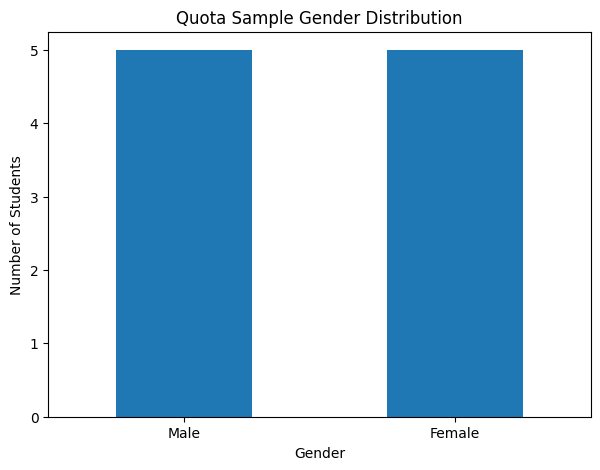

In [26]:
quota_counts = quota_sample['Gender'].value_counts()

quota_counts.plot(kind='bar', figsize=(7,5))

plt.title('Quota Sample Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Students')

plt.xticks(rotation=0)

plt.show()

#Convenience Sampling

In [27]:
convenience_sample=df.head(10)
convenience_sample


,Student_ID,Name,Gender,Age,Department,Marks
0,1,Student_1,Male,24,Computer Science,79
1,2,Student_2,Female,19,Computer Science,40
2,3,Student_3,Male,19,Physics,50
3,4,Student_4,Male,21,Physics,67
4,5,Student_5,Male,19,Physics,96
5,6,Student_6,Female,19,Mathematics,64
6,7,Student_7,Male,23,Mathematics,89
7,8,Student_8,Male,21,Mathematics,62
8,9,Student_9,Male,23,Computer Science,70
9,10,Student_10,Female,24,Mathematics,69


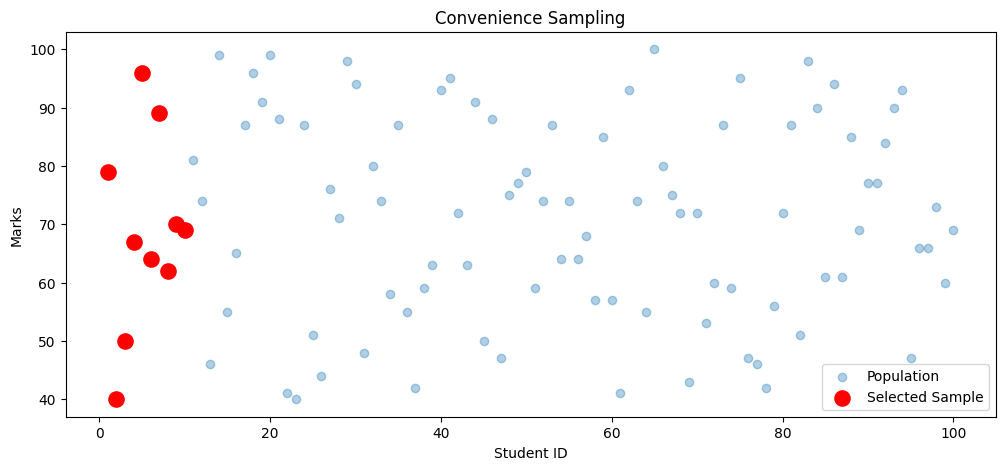

In [28]:
plt.figure(figsize=(12,5))

plt.scatter(df['Student_ID'], df['Marks'], alpha=0.35, label='Population')

plt.scatter(convenience_sample['Student_ID'],
            convenience_sample['Marks'],
            color='red', s=120, label='Selected Sample')

plt.xlabel('Student ID')
plt.ylabel('Marks')
plt.title('Convenience Sampling')
plt.legend()
plt.show()

#Sampling with Replacement

In [29]:
sample_with_replacement= df.sample(n=10, replace=True, random_state=42)
sample_with_replacement

,Student_ID,Name,Gender,Age,Department,Marks
51,52,Student_52,Female,24,Computer Science,74
92,93,Student_93,Female,21,Physics,90
14,15,Student_15,Female,18,Mathematics,55
71,72,Student_72,Female,18,Physics,60
60,61,Student_61,Male,20,Physics,41
20,21,Student_21,Female,22,Mathematics,88
82,83,Student_83,Male,19,Physics,98
86,87,Student_87,Female,20,Mathematics,61
74,75,Student_75,Male,24,Computer Science,95
74,75,Student_75,Male,24,Computer Science,95


In [30]:
print("Selected IDs")
print(sample_with_replacement['Student_ID'].tolist())

print("\nNumber of unique IDs")
print(sample_with_replacement['Student_ID'].nunique())

Selected IDs
[52, 93, 15, 72, 61, 21, 83, 87, 75, 75]

Number of unique IDs
9


#Sampling without Replacement

In [31]:
sample_without_replacement = df.sample(n=10, replace=False, random_state=42)

sample_without_replacement

,Student_ID,Name,Gender,Age,Department,Marks
83,84,Student_84,Female,19,Computer Science,90
53,54,Student_54,Female,21,Computer Science,64
70,71,Student_71,Female,20,Physics,53
45,46,Student_46,Female,22,Computer Science,88
44,45,Student_45,Female,20,Mathematics,50
39,40,Student_40,Male,20,Physics,93
22,23,Student_23,Female,18,Computer Science,40
80,81,Student_81,Male,24,Mathematics,87
10,11,Student_11,Male,24,Computer Science,81
0,1,Student_1,Male,24,Computer Science,79


In [32]:
print("Selected IDs")
print(sample_without_replacement['Student_ID'].tolist())

print("\nNumber of unique IDs")
print(sample_without_replacement['Student_ID'].nunique())

Selected IDs
[84, 54, 71, 46, 45, 40, 23, 81, 11, 1]

Number of unique IDs
10
